## Lecture 12 Example Code 

In [1]:
# Find a Partner

#Consider the 1-on-1 basketball example:

score = "A2B2A2A2A1A1A1A2"

#who wins the game? 



# Computational Thinking Activities: Ants on a Stick

## Problem recap
A straight stick is 10 cm long, labelled from 0 to 9.

Each ant:

* starts at an integer position (0–9),
* walks at 1 cm/s,
* turns around 180° whenever it bumps another ant,
* falls off immediately upon reaching either end (0 or 9).

## Input:
* number of ants,
* a string listing all starting locations.

## Task:
* Determine the minimum and maximum possible time until all ants have fallen off the stick.

## Activity A — Understanding - Abstraction
### Goal:
* Identify only the important information.
* List the necessary details to compute min/max fall‑off time
* List unnecessary physical or behavioural details we can ignore


## Activity B — Understanding - Decomposition

### Goal:
* Break the problem into smaller, understandable pieces.
* Break the real system into core computational steps:

Step 1:

Step 2:

Step 3:

* Write a checklist a simulation or reasoning process will repeat:

 [ ] Determine which ants could fall next
 [ ] Track distances to nearest edge(s)
 [ ] Consider how “collisions” affect timing
 [ ] Update time
 [ ] Continue until all ants have fallen


## Activity C - Design — Logic

### Goal:
* Make the rules precise.
* Fill in the blanks:

* When two ants collide and turn around, their paths behave exactly as if they _______________________.

* Based on this fact, explain why we can compute minimum time by assuming: (one or two sentences)

* Explain why we compute maximum time by assuming: (one or two sentences)


* Write formulas for:

The time for an ant at position p to fall off the left end: ...

The time to fall off the right end: ...

The earliest possible fall time for that ant: ...

The latest possible fall time for that ant: ...

## Activity D — Design - Pattern Recognition

### Goal:
* Notice structure that simplifies the problem.

* What pattern do you observe about collisions and swapping?

* What pattern repeats for each ant when computing min and max?

### Input representation:
* Ant representation (position, direction, etc.):
* Output representation (min time, max time):


## Activity E — Implementation - Algorithm Sketch
### Goal:
* Translate this logic into clear steps.


* Write your algorithm in 6–10 steps (no code)

## Activity F — Evaluation - Validation
### Goal: Test your reasoning with clear examples.

Create three test scenarios:

#### Simple case — One ant in the middle

* Input positions: ________________
* Expected min time: ______
* Expected max time: ______


#### Symmetric ants — Two ants equally spaced
* Input positions: ________________
* Expected min time: ______
* Expected max time: ______


#### Clustered ants — Many ants near one end
* Input positions: ________________
* Expected min time: ______
* Expected max time: ______


Explain why we do not need to simulate collisions directly to find the answers.


## Reflection
Which CT skill helped most for this problem — abstraction, decomposition, logic, patterns, algorithm design, or validation? Why?


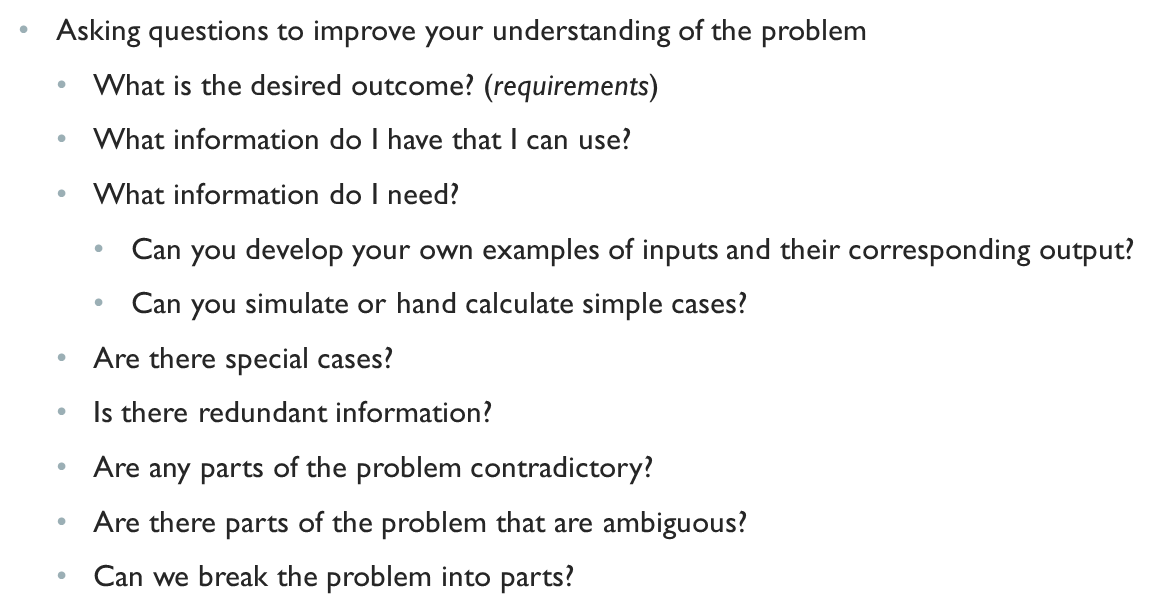
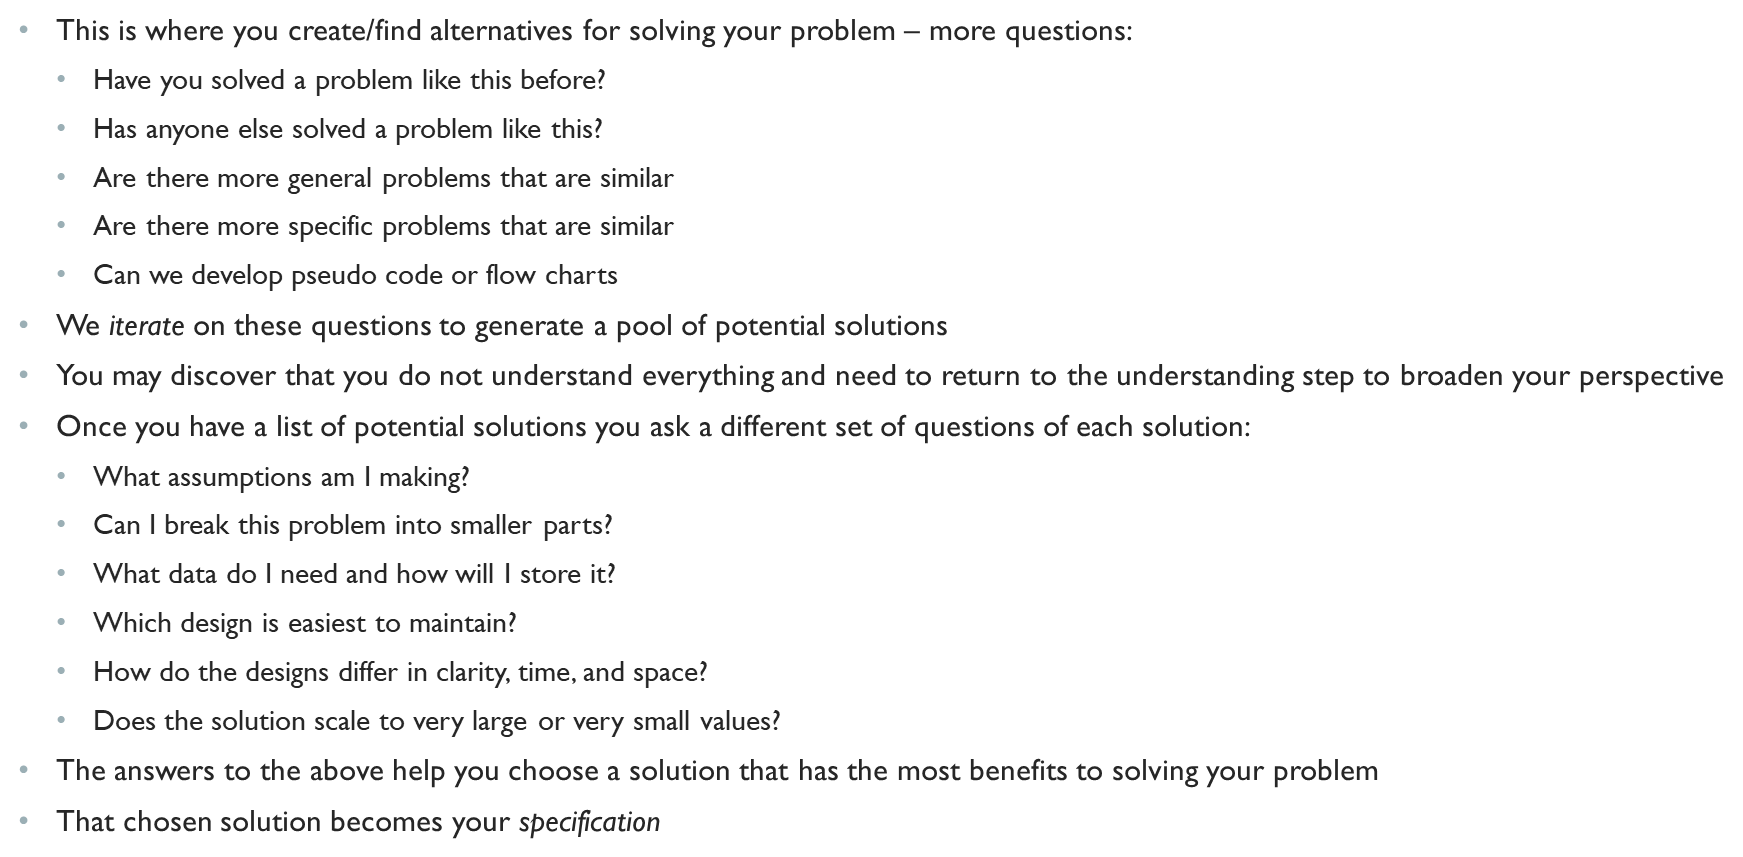

# More find a partner

Consider that ants march on a 1D stick. They all travel at 1 cm per second and the stick is 10 cm long (labelled from 0 to 9). Each time an ant bumps into another ant it turns around 180 degrees and heads the other direction. When an ant reaches the end of the stick it falls off.

What is the minimum time and maximum time in seconds for the stick to be empty?

You are given the number of ants and the starting location for each ant. The starting locations are all integers between 0 and 9 and all locations are given in one string.


In [ ]:
ant_count = 2

#first ant is at the leftmost position on the stick: 0
#second ant is at the rightmost position on the stick: 9
ant_positions = "09"

iteration = 0
for ant in ant_positions:
    #get the position for this ant
    ant_pos = int(ant)
    print(f"ant {iteration} starts at position: {ant_pos} on the stick")
    iteration += 1

# Try at home

Bit Parity

Given a bit string, add a bit to the right side of the string and make sure the parity is even.

```python
in_bit_string = "101"

out_bit_string = "1010"
```

# Understanding 
- inputs?
- outputs?
- smaller tasks?
- edge cases?
- generalization?
- how robust does our solution need to be?

# Design 
- patterns
- abstraction
- develop an algorithm
- develop pseudo code
- reuseable aspects of your code
   
# Implement
- python code
- any challenging aspects to convert from design to python?

# Evaluate
- does your code work for input that is an empty string?
- did you consider robustness?
- how might you further test your solution
- how maintainable is your solution
      - did you use at least one function?



In [ ]:
# code for the bit parity try at home



Debugging



In [6]:

def get_winner(scoring_sequence):
    score_a = 0
    score_b = 0
    index = 0

    while index < len(scoring_sequence):
        current_player = scoring_sequence[index]
        points_scored = int(scoring_sequence[index + 1])

        if current_player == "A":
            score_a = score_a + points_scored
        else:
            score_b = score_b + points_scored

        if score_a >= 11 or score_b >= 11:
            if score_a > score_b:
                return "A"
            else:
                return "B"

        index = index + 2

    # End of sequence: pick the higher score
    if score_a > score_b:
        return "A"
    else:
        return "B"

# 11–0 for A
normal_case_a = "A1" * 11
# 12–0 for B
normal_case_b = "B2" * 6
# 10–10 → 11–10 → 11–13 (B should win)
deuce_case = ("A1B1" * 10) + "A1" + "B1B1B1"

#A win with 11 points
print("Buggy on normal_case_a? (expect A):", get_winner(normal_case_a))
#B wins with 12 points
print("Buggy on normal_case_b? (expect B):", get_winner(normal_case_b))
#B wins with 13 points
print("Buggy on deuce_case? (expect B):", get_winner(deuce_case))  # Prints A!

Buggy on normal_case_a? (expect A): A
Buggy on normal_case_b? (expect B): B
Buggy on deuce_case? (expect B): A


In [3]:
def get_winner_with_trace(scoring_sequence):
    score_a = 0
    score_b = 0
    index = 0

    while index < len(scoring_sequence):
        current_player = scoring_sequence[index]
        points_scored = int(scoring_sequence[index + 1])

        before_a = score_a
        before_b = score_b

        if current_player == "A":
            score_a = score_a + points_scored
        else:
            score_b = score_b + points_scored

        #Print off information each time scoring is recorded to see sequence
        print("Event:", current_player + str(points_scored),
              "| Before:", before_a, "-", before_b,
              "| After:", score_a, "-", score_b)

        # Watch the first time someone hits 11+
        if score_a >= 11 or score_b >= 11:
            lead = score_a - score_b if score_a >= score_b else score_b - score_a
            print("Reached 11+; lead is", lead, "→ returning NOW (this is the bug)")
            if score_a > score_b:
                return "A"
            else:
                return "B"

        index = index + 2

    if score_a > score_b:
        return "A"
    else:
        return "B"

# Run the tracer on the deuce case to *see* the wrong early decision at 11–10
_ = get_winner_with_trace(deuce_case)

Event: A1 | Before: 0 - 0 | After: 1 - 0
Event: B1 | Before: 1 - 0 | After: 1 - 1
Event: A1 | Before: 1 - 1 | After: 2 - 1
Event: B1 | Before: 2 - 1 | After: 2 - 2
Event: A1 | Before: 2 - 2 | After: 3 - 2
Event: B1 | Before: 3 - 2 | After: 3 - 3
Event: A1 | Before: 3 - 3 | After: 4 - 3
Event: B1 | Before: 4 - 3 | After: 4 - 4
Event: A1 | Before: 4 - 4 | After: 5 - 4
Event: B1 | Before: 5 - 4 | After: 5 - 5
Event: A1 | Before: 5 - 5 | After: 6 - 5
Event: B1 | Before: 6 - 5 | After: 6 - 6
Event: A1 | Before: 6 - 6 | After: 7 - 6
Event: B1 | Before: 7 - 6 | After: 7 - 7
Event: A1 | Before: 7 - 7 | After: 8 - 7
Event: B1 | Before: 8 - 7 | After: 8 - 8
Event: A1 | Before: 8 - 8 | After: 9 - 8
Event: B1 | Before: 9 - 8 | After: 9 - 9
Event: A1 | Before: 9 - 9 | After: 10 - 9
Event: B1 | Before: 10 - 9 | After: 10 - 10
Event: A1 | Before: 10 - 10 | After: 11 - 10
Reached 11+; lead is 1 → returning NOW (this is the bug)


In [ ]:
#Bug Code Example
number1 = input("Enter a number:")
number2 = input("Enter another number:")

sum_numbers = number1+number2
print(f"Sum of numbers: {sum_numbers}")

In [5]:
def get_winner_fixed(scoring_sequence):
    score_a = 0
    score_b = 0
    index = 0

    while index < len(scoring_sequence):
        current_player = scoring_sequence[index]
        points_scored = int(scoring_sequence[index + 1])

        if current_player == "A":
            score_a = score_a + points_scored
        else:
            score_b = score_b + points_scored

        # Logic correction: must reach at least 11 AND lead by 2
        lead_for_a = score_a - score_b
        lead_for_b = score_b - score_a
        if (score_a >= 11 or score_b >= 11) and (lead_for_a >= 2 or lead_for_b >= 2):
            if score_a > score_b:
                return "A"
            else:
                return "B"

        index = index + 2

    # If no 2-point lead by 11 occurred in the sequence, choose the higher score
    if score_a > score_b:
        return "A"
    else:
        return "B"

# Run the tracer on the deuce case to *see* the wrong early decision at 11–10
# 11–0 for A
normal_case_a = "A1" * 11
# 12–0 for B
normal_case_b = "B2" * 6
# 10–10 → 11–10 → 11–13 (B should win)
deuce_case = ("A1B1" * 10) + "A1" + "B1B1B1"

#A win with 11 points
print("Buggy on normal_case_a? (expect A):", get_winner(normal_case_a))
#B wins with 12 points
print("Buggy on normal_case_b? (expect B):", get_winner(normal_case_b))
#B wins with 13 points
print("Buggy on deuce_case? (expect B):", get_winner(deuce_case))  # Prints B!